In [2]:
import importlib
import aaro_draft
import pandas as pd
import matplotlib.pyplot as plt
import Conor
from IPython.display import Image, display
from joblib import Parallel, delayed
import Conor as c

# Reward 1

In [3]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -37.528

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -36.670

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -35.692

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -28.568

--- Running: scaling=1 ---
    Done. Final mean VPI: -20.951

--- Running: scaling=5 ---
    Done. Final mean VPI: -3.749

--- Running: scaling=10 ---
    Done. Final mean VPI: -3.815

--- Running: scaling=50 ---
    Done. Final mean VPI: -59.194

--- Running: scaling=100 ---
    Done. Final mean VPI: -100.689

--- Running: scaling=500 ---
    Done. Final mean VPI: -150.407


In [4]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-74625.597959,-37.528148,218.2,218.140
1,0.05,-72526.366563,-36.670411,217.9,217.726
2,0.10,-70528.823156,-35.692036,217.3,216.823
3,0.50,-57344.404609,-28.567765,217.9,217.222
4,1.00,-44153.660198,-20.951454,218.5,218.197
5,5.00,-14694.665262,-3.748748,224.8,223.351
6,10.00,-14181.646369,-3.815422,219.7,217.360
7,50.00,-134881.975162,-59.194151,214.3,213.937
8,100.00,-217959.591809,-100.688642,211.9,210.685
9,500.00,-281302.894158,-150.406926,217.0,216.985


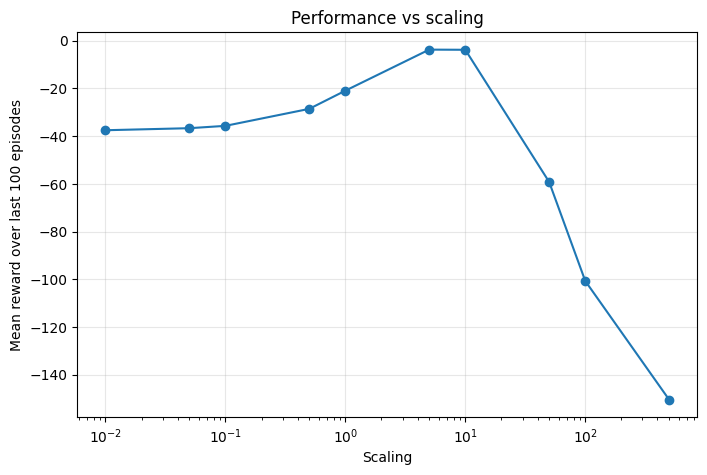

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

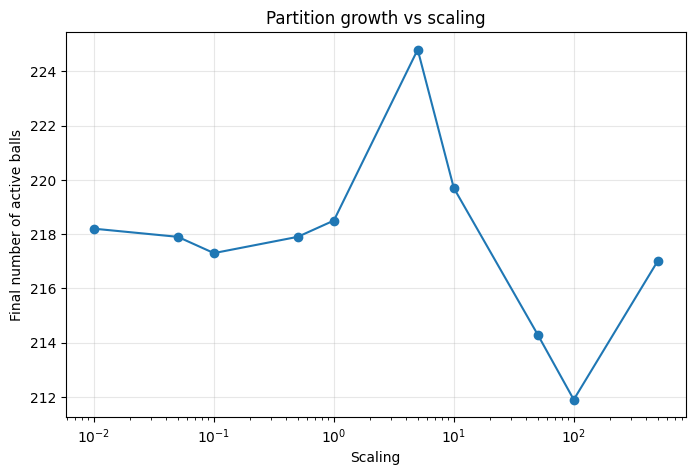

In [6]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

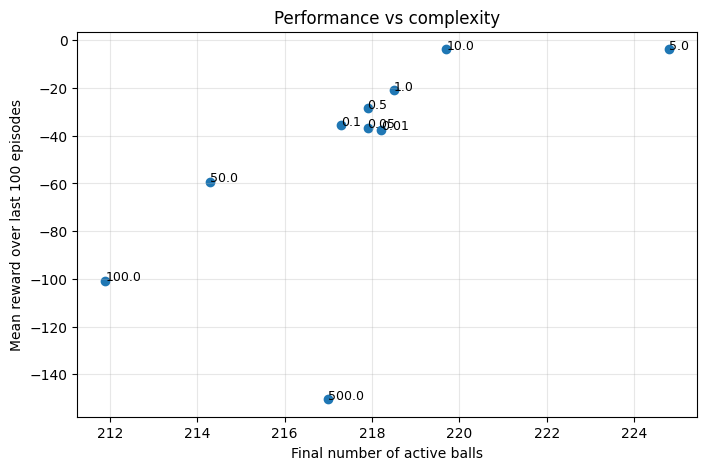

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()

# Reward 2


In [8]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_shifted,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -8.442

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -7.984

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -7.424

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -4.572

--- Running: scaling=1 ---
    Done. Final mean VPI: -2.238

--- Running: scaling=5 ---
    Done. Final mean VPI: -1.470

--- Running: scaling=10 ---
    Done. Final mean VPI: -3.666

--- Running: scaling=50 ---
    Done. Final mean VPI: -33.135

--- Running: scaling=100 ---
    Done. Final mean VPI: -52.120

--- Running: scaling=500 ---
    Done. Final mean VPI: -63.421


In [9]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-16559.971447,-8.442472,221.8,219.952
1,0.05,-15733.511902,-7.984399,220.3,219.286
2,0.10,-14429.701846,-7.423865,222.4,220.846
3,0.50,-9545.847002,-4.571509,223.3,220.528
4,1.00,-5749.991036,-2.238490,225.1,223.840
5,5.00,-4412.691008,-1.470108,213.1,211.873
6,10.00,-9778.296838,-3.666200,211.6,207.421
7,50.00,-73695.392906,-33.134878,208.0,207.862
8,100.00,-106203.621255,-52.119812,211.0,211.000
9,500.00,-120314.528832,-63.421061,216.7,216.700


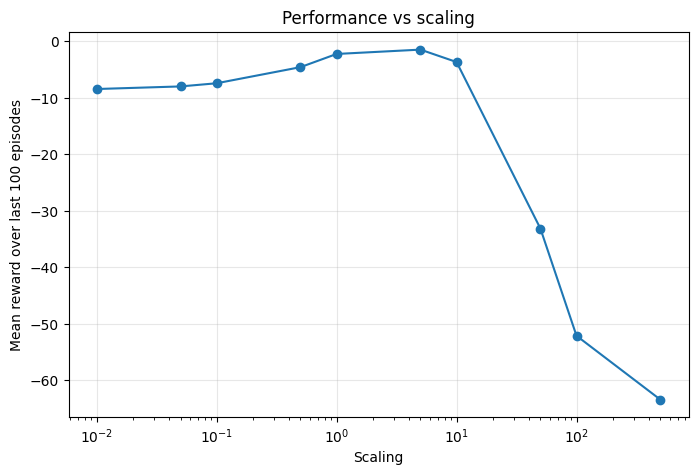

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

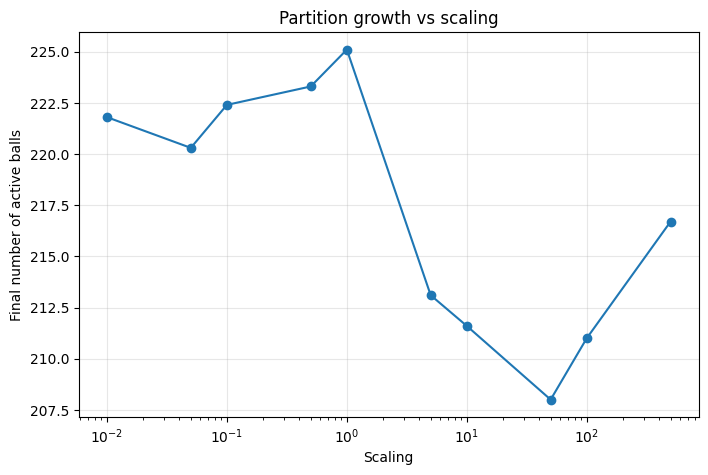

In [12]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

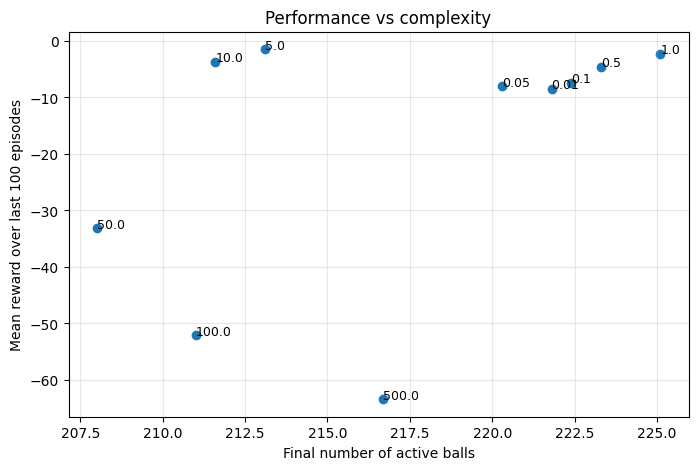

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()